In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import duckdb
#Connexion à la base de données DuckDB
con = duckdb.connect(database='lactate.duckdb', read_only=False)
print("Connexion à la base de données réussie !")

Connexion à la base de données réussie !


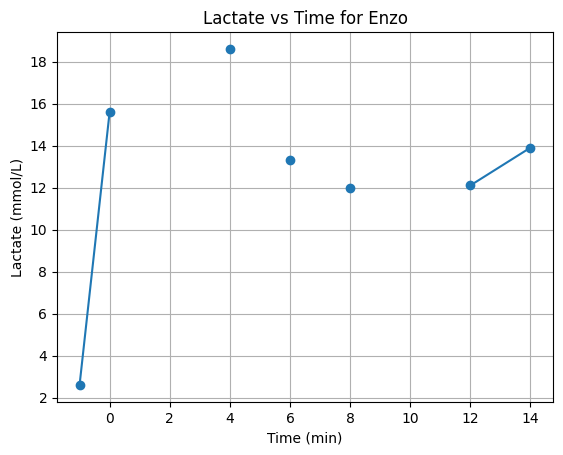

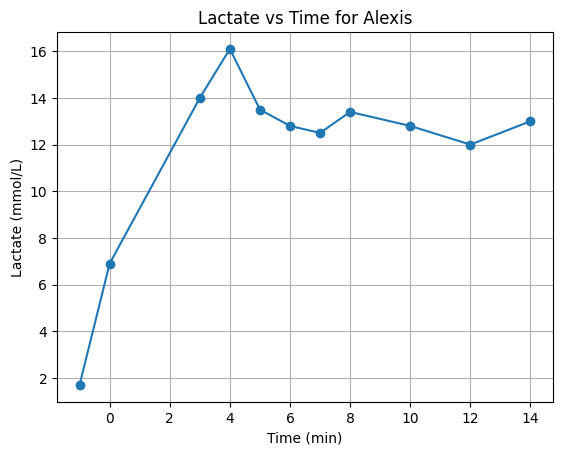

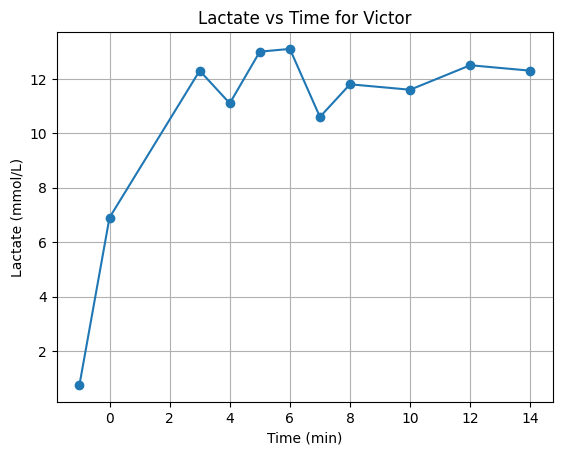

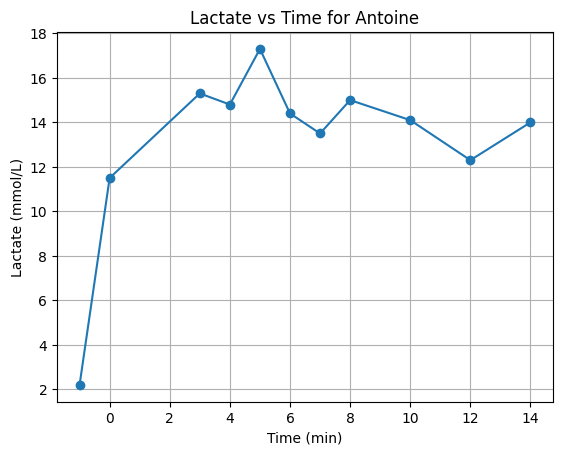

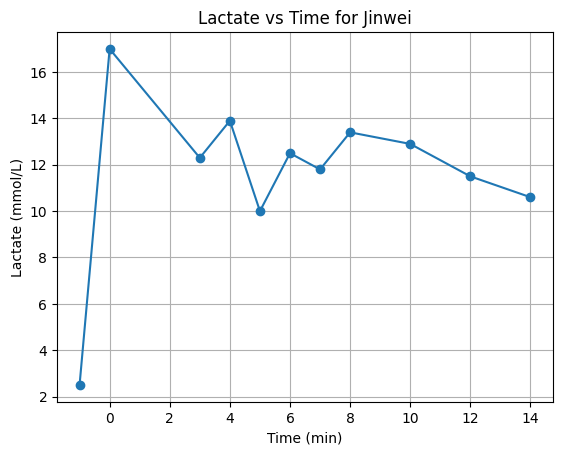

In [22]:
#Tracer pour chaque sujet la courbe de lactate en fonction du temps
#Un graphique par sujet 

query = "SELECT subject_name, time_min, lactate_mmol_l FROM lactate_data"
df = con.execute(query).fetchdf()
subjects = df['subject_name'].unique()
for subject in subjects:
    subject_data = df[df['subject_name'] == subject]
    plt.figure()
    plt.plot(subject_data['time_min'], subject_data['lactate_mmol_l'], marker='o')
    plt.title(f'Lactate vs Time for {subject}')
    plt.xlabel('Time (min)')
    plt.ylabel('Lactate (mmol/L)')
    plt.grid()
    plt.show()

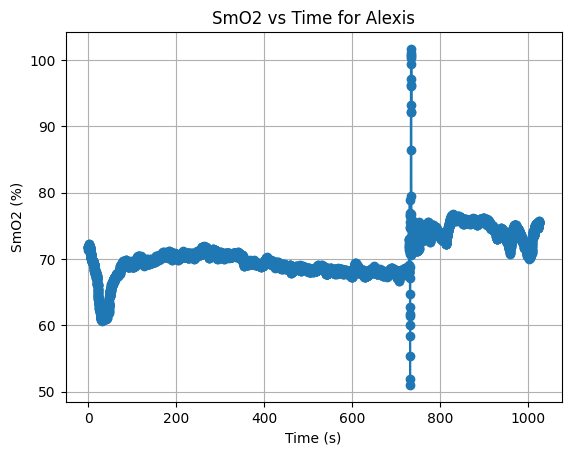

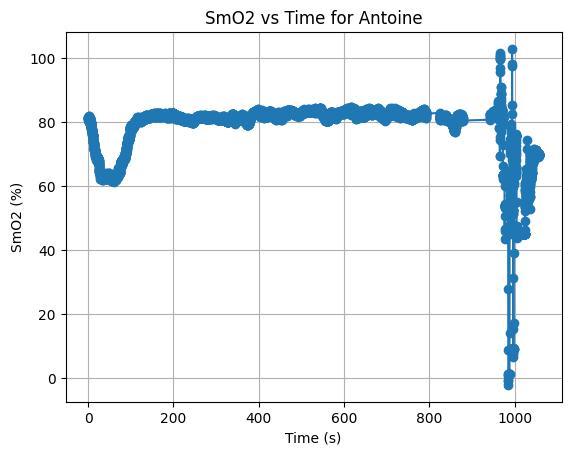

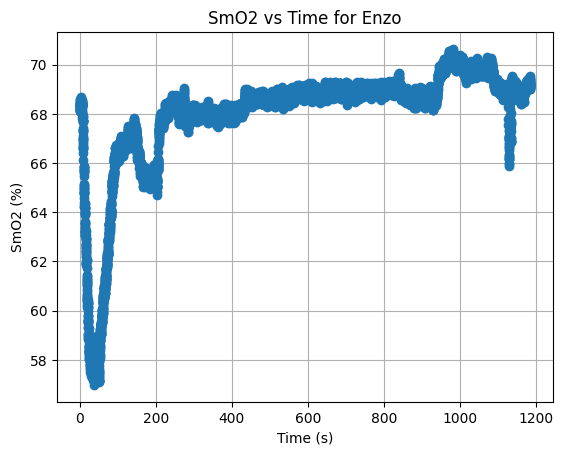

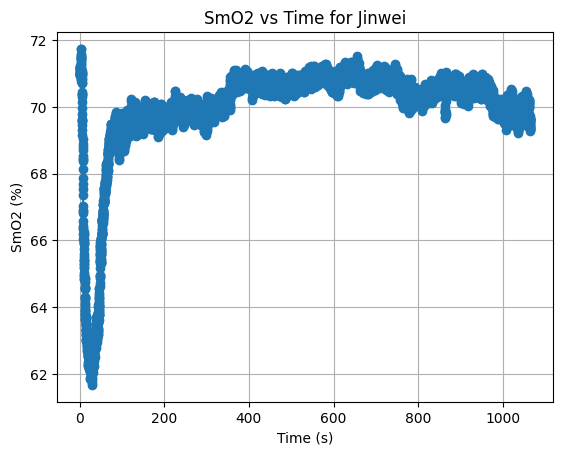

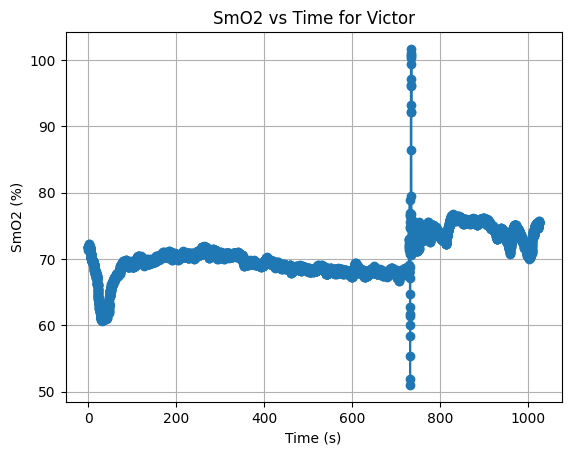

In [23]:
#Tracer pour chaque sujet la courbe de SmO2 en fonction du temps
# Un graphique par sujet
query = "SELECT subject_name, timestamp_s, smo2, hbdiff FROM sensor_timeseries"
df = con.execute(query).fetchdf()
subjects = df['subject_name'].unique()
for subject in subjects:
    subject_data = df[df['subject_name'] == subject]
    plt.figure()
    plt.plot(subject_data['timestamp_s'], subject_data['smo2'], marker='o')
    plt.title(f'SmO2 vs Time for {subject}')
    plt.xlabel('Time (s)')
    plt.ylabel('SmO2 (%)')
    plt.grid()
    plt.show()